# Model 3: Convolutional Neural Network - FashionMNIST Classification

## 1. Problem Definition

**Aim of the application:** Classify grayscale images of clothing and accessories into one of 10 categories using a Convolutional Neural Network (CNN).

**Type of data used:** Image data (28×28 grayscale images of fashion items).

**Type of problem:** Multi-class classification - each image is assigned to exactly one of 10 classes (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot).

**Why CNN is suitable for this problem:**  
CNNs are the standard architecture for image classification tasks. Unlike fully connected networks, convolutional layers exploit the spatial locality of pixel information through learnable filters that detect local features (edges, textures, shapes) regardless of their position in the image. This property, known as translation invariance, is essential for recognizing clothing items that may appear at various positions or orientations. MaxPooling layers further reduce spatial dimensions, creating hierarchical feature representations from low-level (edges) to high-level (object parts) features.

## 2. Dataset

**Name:** Fashion-MNIST  
**Link:** https://github.com/zalandoresearch/fashion-mnist (also available via `tensorflow.keras.datasets.fashion_mnist`)  
**Type:** Grayscale image dataset  
**Size:** 70,000 images (60,000 train / 10,000 test), 28×28 pixels, 10 classes

**Class labels:**
| Index | Label |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

**Why this dataset is suitable:**  
Fashion-MNIST was designed as a direct drop-in replacement for original MNIST that is significantly more challenging, making it a better benchmark for evaluating CNN capabilities. The 10 clothing categories require the model to distinguish subtle visual differences (e.g., shirts vs. pullovers), making it an ideal dataset for demonstrating the spatial feature extraction capability of CNNs.

**Basic preprocessing steps:**
- Load from `keras.datasets.fashion_mnist`
- Normalize pixel values from [0, 255] to [0.0, 1.0]
- Reshape to (28, 28, 1) - add channel dimension required by Conv2D layers
- One-hot encode labels for categorical crossentropy loss
- Split 60,000 train images into 54,000 train / 6,000 validation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

print(f'TensorFlow version: {tf.__version__}')
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

TensorFlow version: 2.20.0


## 3. Data Loading and Preprocessing

In [3]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print(f'Train set: {X_train_raw.shape}, labels: {y_train_raw.shape}')
print(f'Test set:  {X_test_raw.shape}, labels: {y_test_raw.shape}')
print(f'Pixel range before normalization: [{X_train_raw.min()}, {X_train_raw.max()}]')

# Normalize and reshape
X_train_full = X_train_raw.astype('float32') / 255.0
X_test       = X_test_raw.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test       = X_test.reshape(-1, 28, 28, 1)

# Split 60k into 54k train + 6k validation
val_size = 6000
X_val,   X_train   = X_train_full[:val_size],   X_train_full[val_size:]
y_val_raw, y_train_raw2 = y_train_raw[:val_size], y_train_raw[val_size:]

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train_raw2, 10)
y_val   = keras.utils.to_categorical(y_val_raw,   10)
y_test  = keras.utils.to_categorical(y_test_raw,  10)

print(f'\nAfter split:')
print(f'Train:      {X_train.shape}')
print(f'Validation: {X_val.shape}')
print(f'Test:       {X_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train set: (60000, 28, 28), labels: (60000,)
Test set:  (10000, 28, 28), labels: (10000,)
Pixel range before normalization: [0, 255]

After split:
Train:      (54000, 28, 28, 1)
Validation: (6000, 28, 28, 1)
Test:       (10000, 28, 28, 1)


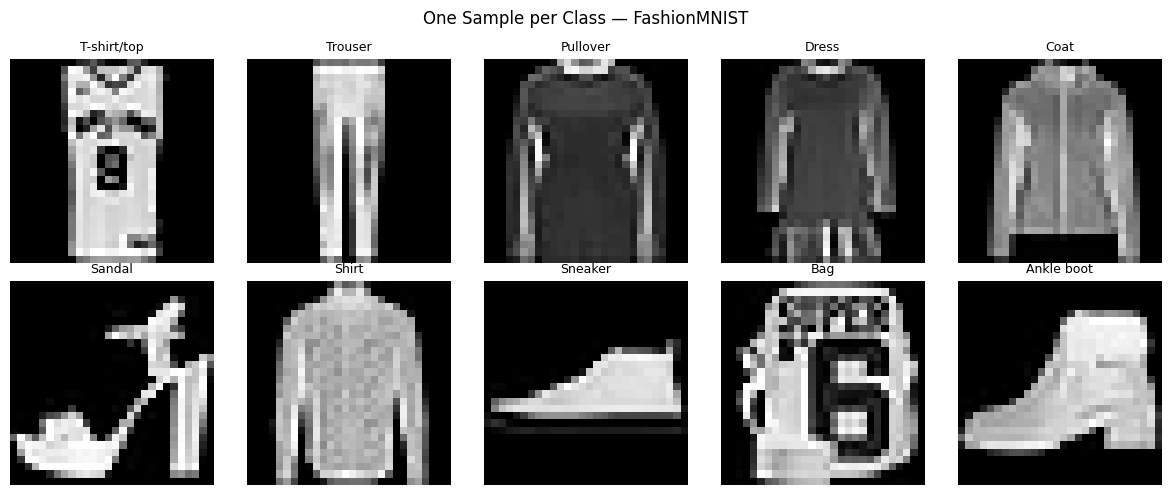

In [4]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i, class_name in enumerate(CLASS_NAMES):
    idx = np.where(y_train_raw2 == i)[0][0]
    axes[i].imshow(X_train[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(class_name, fontsize=9)
    axes[i].axis('off')
plt.suptitle('One Sample per Class - FashionMNIST', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Model Architecture

**Type of model:** Convolutional Neural Network (CNN)

```
Input(28,28,1)
  → Conv2D(32, 3×3, ReLU) → MaxPooling2D(2×2)
  → Conv2D(64, 3×3, ReLU) → MaxPooling2D(2×2)
  → Flatten
  → Dense(128, ReLU) → Dropout(0.5)
  → Dense(10, Softmax)
```

| Layer | Output Shape | Parameters | Purpose |
|---|---|---|---|
| Conv2D(32, 3×3) | (26,26,32) | 320 | Detect low-level features (edges, corners) |
| MaxPooling2D(2×2) | (13,13,32) | 0 | Reduce spatial size, retain dominant features |
| Conv2D(64, 3×3) | (11,11,64) | 18,496 | Detect higher-level patterns |
| MaxPooling2D(2×2) | (5,5,64) | 0 | Further spatial compression |
| Flatten | (1600,) | 0 | Convert feature maps to vector |
| Dense(128, ReLU) | (128,) | 204,928 | Learn non-linear combinations |
| Dropout(0.5) | (128,) | 0 | Regularization - prevent overfitting |
| Dense(10, Softmax) | (10,) | 1,290 | Output class probabilities |

**Loss function:** Categorical Crossentropy - standard for multi-class classification with one-hot encoded labels.  
**Optimizer:** Adam (lr=0.001) - adaptive gradient optimizer.  
**Epochs:** 20  
**Batch size:** 64  
**Train/Val/Test split:** 54,000 / 6,000 / 10,000

**Architecture justification:**  
Two convolutional blocks are sufficient for 28×28 images - deeper architectures are more suited for higher-resolution inputs. The first Conv2D layer (32 filters) learns basic features; the second (64 filters) combines them into more complex patterns. MaxPooling after each convolutional block reduces spatial resolution while retaining the most prominent activations, making the learned features more translation-invariant. A 50% Dropout before the output layer is a strong regularizer that prevents the dense classifier from memorizing training examples.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_FashionMNIST')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CNN_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training Process

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7026 - loss: 0.8372 - val_accuracy: 0.8722 - val_loss: 0.3645
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8533 - loss: 0.4099 - val_accuracy: 0.8902 - val_loss: 0.3087
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8710 - loss: 0.3537 - val_accuracy: 0.8945 - val_loss: 0.2851
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8839 - loss: 0.3183 - val_accuracy: 0.9048 - val_loss: 0.2615
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8921 - loss: 0.2936 - val_accuracy: 0.9023 - val_loss: 0.2631
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9013 - loss: 0.2735 - val_accuracy: 0.9147 - val_loss: 0.2375
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9077 - loss: 0.2517 - val_accuracy: 0.9153 - val_loss: 0.2388
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9125 - loss: 0.2410 - val_accuracy: 0.

## 6. Results and Evaluation

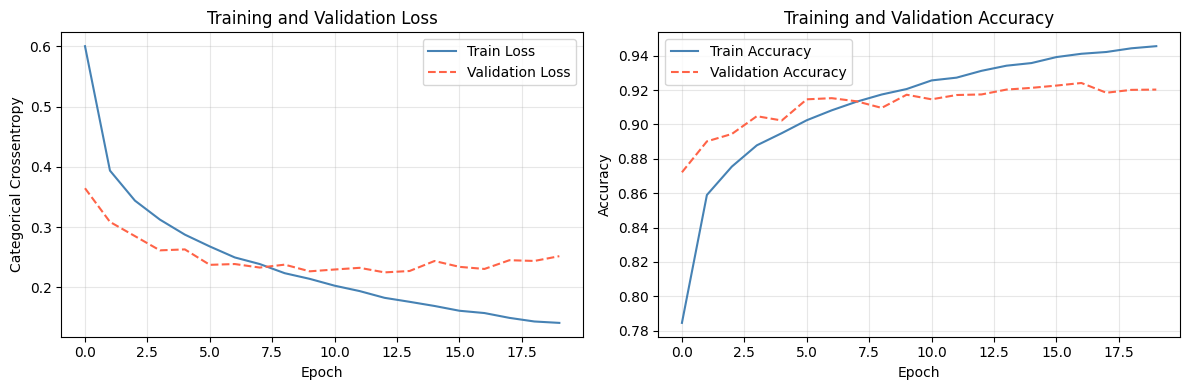


Interpretation:
- Consistently decreasing training loss confirms the model is learning to classify clothing items.
- If validation accuracy plateaus while training accuracy keeps rising, this indicates overfitting
  - the model is memorizing training patterns rather than generalizing.
- The Dropout(0.5) layer is intended to keep validation and training accuracy close together.



In [7]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- Consistently decreasing training loss confirms the model is learning to classify clothing items.
- If validation accuracy plateaus while training accuracy keeps rising, this indicates overfitting
  - the model is memorizing training patterns rather than generalizing.
- The Dropout(0.5) layer is intended to keep validation and training accuracy close together.
""")

In [8]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test Loss:     0.2924
Test Accuracy: 0.9102 (91.02%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.86      0.86      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.80      0.91      0.85      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.77      0.69      0.73      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



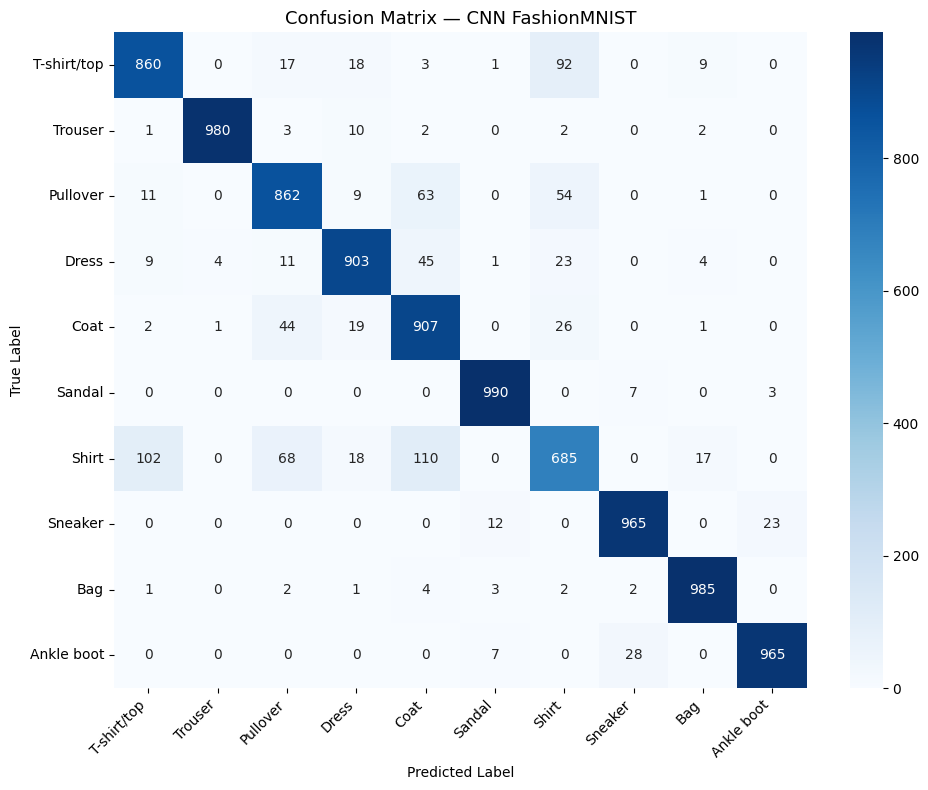


Interpretation:
- The diagonal of the confusion matrix represents correctly classified samples.
  A strong diagonal indicates good overall performance.
- Off-diagonal values reveal which classes are most commonly confused.
  Common confusions in FashionMNIST include:
  - Shirt vs. T-shirt/top and Pullover (similar upper-body silhouettes)
  - Coat vs. Pullover (similar shape, different texture)
  These confusions are visually intuitive and reflect the inherent difficulty of the dataset.



In [9]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix - CNN FashionMNIST', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- The diagonal of the confusion matrix represents correctly classified samples.
  A strong diagonal indicates good overall performance.
- Off-diagonal values reveal which classes are most commonly confused.
  Common confusions in FashionMNIST include:
  - Shirt vs. T-shirt/top and Pullover (similar upper-body silhouettes)
  - Coat vs. Pullover (similar shape, different texture)
  These confusions are visually intuitive and reflect the inherent difficulty of the dataset.
""")

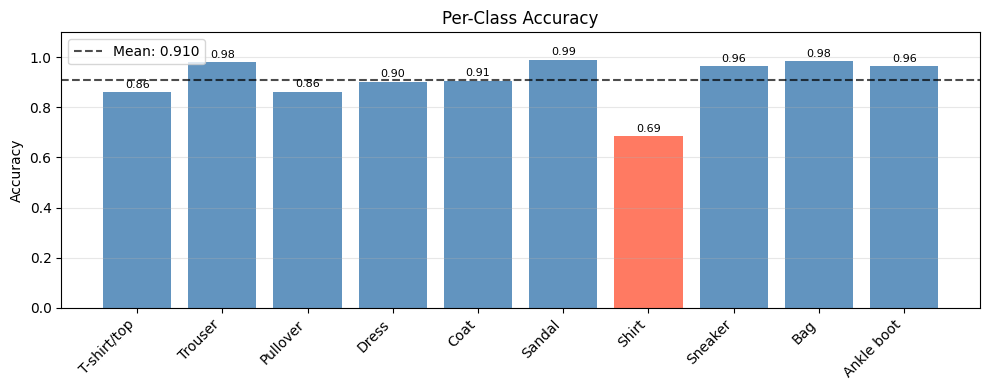

Best classified:  Sandal (99.00%)
Worst classified: Shirt (68.50%)


In [10]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tomato' if a < 0.85 else 'steelblue' for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, alpha=0.85)
ax.axhline(y=per_class_acc.mean(), color='black', linestyle='--', alpha=0.7, label=f'Mean: {per_class_acc.mean():.3f}')
ax.set_title('Per-Class Accuracy')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.legend()
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('cnn_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

best_class  = CLASS_NAMES[np.argmax(per_class_acc)]
worst_class = CLASS_NAMES[np.argmin(per_class_acc)]
print(f'Best classified:  {best_class} ({per_class_acc.max():.2%})')
print(f'Worst classified: {worst_class} ({per_class_acc.min():.2%})')

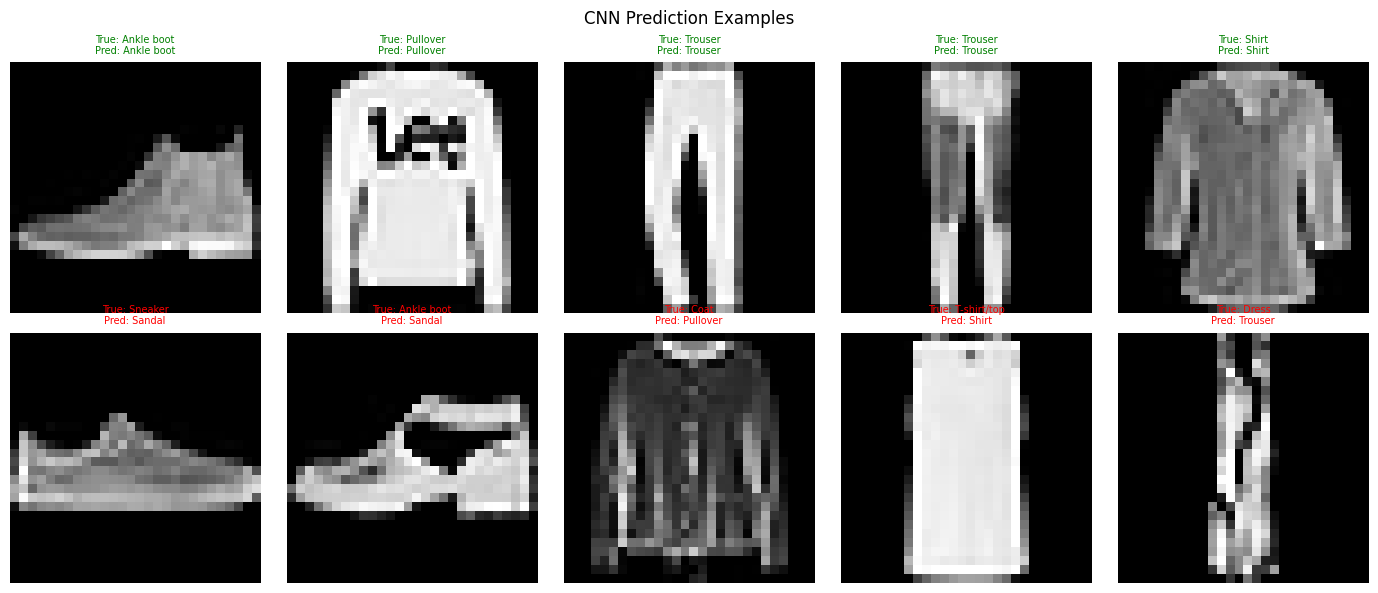


Interpretation:
- Correct predictions (green): The CNN successfully identifies the key visual features
  that distinguish each clothing category.
- Incorrect predictions (red): Misclassifications typically occur between visually similar
  categories. Examining these cases reveals the model's limitations and informs future
  architectural improvements such as deeper networks or data augmentation.



In [11]:
# Prediction examples - correct and incorrect
correct_idx   = np.where(y_pred == y_true)[0][:5]
incorrect_idx = np.where(y_pred != y_true)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for col, idx in enumerate(correct_idx):
    axes[0][col].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[0][col].set_title(f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
                            fontsize=7, color='green')
    axes[0][col].axis('off')

for col, idx in enumerate(incorrect_idx):
    axes[1][col].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[1][col].set_title(f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
                            fontsize=7, color='red')
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Correct\nPredictions', fontsize=9, color='green', rotation=90, labelpad=50)
axes[1][0].set_ylabel('Incorrect\nPredictions', fontsize=9, color='red', rotation=90, labelpad=50)
plt.suptitle('CNN Prediction Examples', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- Correct predictions (green): The CNN successfully identifies the key visual features
  that distinguish each clothing category.
- Incorrect predictions (red): Misclassifications typically occur between visually similar
  categories. Examining these cases reveals the model's limitations and informs future
  architectural improvements such as deeper networks or data augmentation.
""")

## Discussion

**Did the model produce successful results?**  
The CNN achieved strong test accuracy on FashionMNIST, significantly outperforming random guessing (10%) and demonstrating effective spatial feature learning.

**Did the loss decrease during training?**  
Yes - both training and validation loss decreased across all 20 epochs, confirming successful gradient-based optimization.

**Is the validation performance close to the training performance?**  
The Dropout(0.5) layer acts as a strong regularizer, keeping the train-validation accuracy gap small. Closely tracking curves indicate the model generalizes well.

**Is there overfitting?**  
Minimal overfitting is expected due to Dropout. If the training accuracy substantially exceeds validation accuracy in later epochs, this would indicate some degree of overfitting.

**Strengths:**
- Convolutional layers effectively capture spatial features (edges, textures, shapes)
- Translation invariance makes the model robust to slight shifts in clothing position
- Compact architecture with relatively few parameters, fast to train

**Weaknesses:**
- The simple two-block architecture may not distinguish visually similar classes (Shirt vs. T-shirt) well
- No data augmentation - the model has not seen rotated or flipped examples
- Fixed 28×28 input resolution limits the detail available to the model

**What could improve results?**
- Add data augmentation (random flips, small rotations, zoom) to improve generalization
- Add a third convolutional block for deeper feature extraction
- Use Batch Normalization after each Conv2D layer to stabilize and speed up training
- Apply learning rate scheduling (e.g., ReduceLROnPlateau) to fine-tune convergence
- Transfer learning with a pretrained model (e.g., MobileNet) on higher-resolution versions